# 02 — Compare models

Runs every registered model on poetry + prose, scores them via the official scorer, and plots a comparison.

## How to add your own model

1. Edit [`src/latinbench/models/template.py`](../src/latinbench/models/template.py) — subclass `Model`, set `name`, implement `predict`.
2. Re-run the cells below.

Results are cached under `predictions/<model.name>/scores.json`. While iterating, either bump `MyModel.name` or pass `force=True` to skip the cache.

In [2]:
%load_ext autoreload
%autoreload 2

from latinbench import Bench, MODELS
from latinbench.models.template import MyModel
from latinbench.models import UdpipeModel


## Explore registered models

Peek at what's available and which version of each will run before kicking off the bench.

In [ ]:
from latinbench.models.udpipe import list_perseus_models, DEFAULT_MODEL_ID

print('Registered models (MODELS):')
for key in ('udpipe', 'latinpipe', 'qwen3-lmstudio',
            'qwen3-vl-8b-lmstudio', 'gemma-3-12b-lmstudio'):
    m = MODELS[key]
    print(f'  {key:22s}  -> {m.name}')
print(f'  {MyModel.name:22s}  (local template — edit src/latinbench/models/template.py)')

print()
print('All available UDPipe versions on LINDAT:')
for mid in list_perseus_models():
    marker = '*' if mid == DEFAULT_MODEL_ID else ' '
    print(f' {marker} {mid}')
print()
print("* = current default. Use UdpipeModel('<id>') to try a different one.")

## Run all three models

In [3]:

bench = Bench()
df = bench.compare([
    UdpipeModel('latin-perseus-ud-2.15-241121'),
    UdpipeModel('latin-perseus-ud-2.17-251125'),
    MODELS['latinpipe'],
    MODELS['qwen3-lmstudio'],
])
df

[qwen3-0.6b-mlx] predicting poetry…
[qwen3-0.6b-mlx] 25/555 sentences
[qwen3-0.6b-mlx] 50/555 sentences
[qwen3-0.6b-mlx] 75/555 sentences
[qwen3-0.6b-mlx] 100/555 sentences
[qwen3-0.6b-mlx] 125/555 sentences
[qwen3-0.6b-mlx] 150/555 sentences
[qwen3-0.6b-mlx] 175/555 sentences
[qwen3-0.6b-mlx] 200/555 sentences
[qwen3-0.6b-mlx] 225/555 sentences
[qwen3-0.6b-mlx] 250/555 sentences
[qwen3-0.6b-mlx] 275/555 sentences
[qwen3-0.6b-mlx] 300/555 sentences
[qwen3-0.6b-mlx] 325/555 sentences
[qwen3-0.6b-mlx] 350/555 sentences
[qwen3-0.6b-mlx] 375/555 sentences
[qwen3-0.6b-mlx] 400/555 sentences
[qwen3-0.6b-mlx] 425/555 sentences
[qwen3-0.6b-mlx] 450/555 sentences
[qwen3-0.6b-mlx] 475/555 sentences
[qwen3-0.6b-mlx] 500/555 sentences
[qwen3-0.6b-mlx] 525/555 sentences
[qwen3-0.6b-mlx] 550/555 sentences
[qwen3-0.6b-mlx] 555/555 sentences
[qwen3-0.6b-mlx] 555 sentences, 7714 tokens; 4443 fallback tokens (57.6%) across 265 sentences
[qwen3-0.6b-mlx] scoring poetry…
[qwen3-0.6b-mlx] predicting prose…

,system,split,metric,P,R,F1
0,latin-perseus-ud-2.15-241121,poetry,UAS,59.87,59.87,59.87
1,latin-perseus-ud-2.15-241121,poetry,LAS,50.78,50.78,50.78
2,latin-perseus-ud-2.15-241121,poetry,CLAS,49.20,49.30,49.25
3,latin-perseus-ud-2.15-241121,prose,UAS,64.56,64.56,64.56
4,latin-perseus-ud-2.15-241121,prose,LAS,57.68,57.68,57.68
5,latin-perseus-ud-2.15-241121,prose,CLAS,53.72,53.12,53.42
6,latin-perseus-ud-2.17-251125,poetry,UAS,68.98,68.98,68.98
7,latin-perseus-ud-2.17-251125,poetry,LAS,61.19,61.19,61.19
8,latin-perseus-ud-2.17-251125,poetry,CLAS,59.91,59.89,59.90
9,latin-perseus-ud-2.17-251125,prose,UAS,69.33,69.33,69.33


## LAS comparison

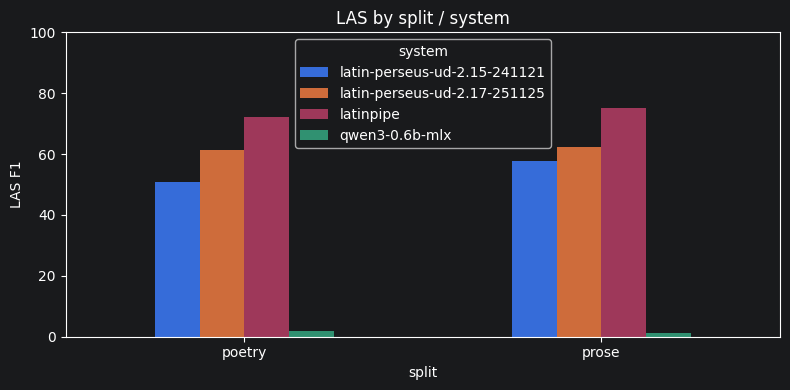

In [4]:
bench.plot(df, metric='LAS')

## CLAS comparison

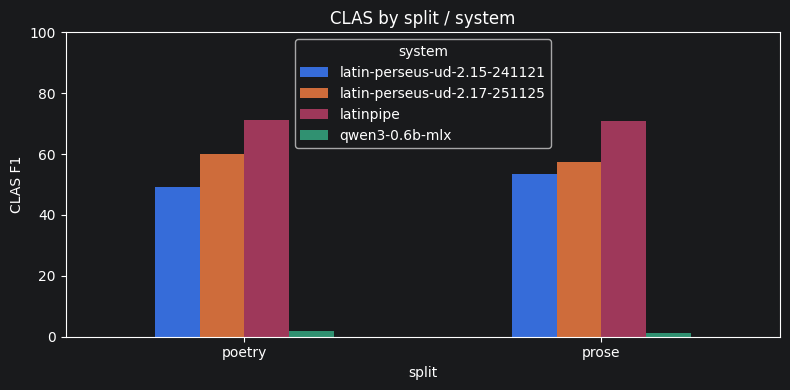

In [5]:
bench.plot(df, metric='CLAS')

## Force a re-run for one model

While iterating on `MyModel`, either bump `name` (results cached per name) or:

In [6]:
bench.run(MyModel(), force=True)

[my_model] predicting poetry…
[my_model] scoring poetry…
[my_model] predicting prose…
[my_model] scoring prose…


{'poetry': {'Tokens': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'Sentences': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'Words': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'UPOS': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'XPOS': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'UFeats': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'AllTags': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'Lemmas': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'UAS': {'P': 21.88, 'R': 21.88, 'F1': 21.88},
  'LAS': {'P': 1.14, 'R': 1.14, 'F1': 1.14},
  'CLAS': {'P': 1.14, 'R': 1.36, 'F1': 1.24},
  'MLAS': {'P': 0.96, 'R': 1.15, 'F1': 1.04},
  'BLEX': {'P': 1.14, 'R': 1.36, 'F1': 1.24}},
 'prose': {'Tokens': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'Sentences': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'Words': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'UPOS': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'XPOS': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'UFeats': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'AllTags': {'P': 100.0, 'R': 100.0, 

## Running just one model

In [7]:
bench.run(MODELS['latinpipe'])  # cached after the first run

{'poetry': {'Tokens': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'Sentences': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'Words': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'UPOS': {'P': 94.43, 'R': 94.43, 'F1': 94.43},
  'XPOS': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'UFeats': {'P': 66.39, 'R': 66.39, 'F1': 66.39},
  'AllTags': {'P': 64.27, 'R': 64.27, 'F1': 64.27},
  'Lemmas': {'P': 82.95, 'R': 82.95, 'F1': 82.95},
  'UAS': {'P': 78.35, 'R': 78.35, 'F1': 78.35},
  'LAS': {'P': 72.27, 'R': 72.27, 'F1': 72.27},
  'CLAS': {'P': 71.16, 'R': 71.4, 'F1': 71.28},
  'MLAS': {'P': 42.59, 'R': 42.73, 'F1': 42.66},
  'BLEX': {'P': 58.91, 'R': 59.11, 'F1': 59.01}},
 'prose': {'Tokens': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'Sentences': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'Words': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'UPOS': {'P': 94.52, 'R': 94.52, 'F1': 94.52},
  'XPOS': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'UFeats': {'P': 84.97, 'R': 84.97, 'F1': 84.97},
  'AllTags': {'P': 81.78, '

## Try the local LLM (LM Studio)

A third reference model, `qwen3-lmstudio`, runs **Qwen3-0.6B locally via LM Studio** (MLX runtime on Apple Silicon) and parses each sentence with constrained JSON-schema structured output. It's intentionally a weak baseline (0.6B params on a hard structural task) — included as a plumbing example for LLM-based parsing rather than for the leaderboard.

**One-time setup** (skip if already done):

1. Install [LM Studio](https://lmstudio.ai/).
2. In the **Discover** tab, search for `Qwen3 0.6B MLX` and download `lmstudio-community/Qwen3-0.6B-MLX-4bit` (~400 MB).
3. Go to the **Developer** tab → load the model → click **Start Server** (defaults to port 1234).
4. Recommended server settings: max parallel requests → 8, Flash Attention → on, KV cache → q8_0.
5. Sanity check: `curl http://localhost:1234/v1/models` should list the loaded model.

The cell below runs the full bench on the LLM. Expect **many minutes** on a 0.6B model — results cache to `predictions/<slug>/scores.json`, so re-runs are instant. The end-of-run summary reports how many tokens fell back (invalid head, malformed output) separately from LAS/CLAS.

In [8]:
bench.run(MODELS['qwen3-lmstudio'])  # cached after the first run

# To try a different model loaded in LM Studio (each model id gets its own
# predictions/<slug>/ cache dir; pass the exact id LM Studio reports for
# `GET /v1/models`):
# from latinbench.models.lmstudio_llm import LMStudioModel
# bench.run(LMStudioModel('qwen/qwen3-4b'))
# bench.run(LMStudioModel('qwen/qwen3-8b'))

{'poetry': {'Tokens': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'Sentences': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'Words': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'UPOS': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'XPOS': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'UFeats': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'AllTags': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'Lemmas': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'UAS': {'P': 17.35, 'R': 17.35, 'F1': 17.35},
  'LAS': {'P': 1.94, 'R': 1.94, 'F1': 1.94},
  'CLAS': {'P': 1.84, 'R': 2.11, 'F1': 1.96},
  'MLAS': {'P': 1.34, 'R': 1.53, 'F1': 1.43},
  'BLEX': {'P': 1.84, 'R': 2.11, 'F1': 1.96}},
 'prose': {'Tokens': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'Sentences': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'Words': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'UPOS': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'XPOS': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'UFeats': {'P': 100.0, 'R': 100.0, 'F1': 100.0},
  'AllTags': {'P': 100.0, 'R': 100.0, 

## Why does qwen3-lmstudio do so poorly? (LLM error analysis)

Run this cell once `qwen3-lmstudio` has finished scoring. It dissects the predictions
to show *how* the LLM fails — not just *that* it fails. Three pieces:

- **Per-token error breakdown.** Of the four possible outcomes (both right / only head right / only label right / both wrong), where do most tokens land?
- **Label distribution: gold vs predicted.** Reveals whether the model is hallucinating a tiny vocabulary of labels (English-style `det`, `nsubj`) rather than picking from the full UD inventory.
- **Per-relation accuracy.** For each gold relation type, how often does the model get the parent right? The label?


Per-token error breakdown (%):
error_type  both wrong  correct  head right, label wrong  \
split                                                      
poetry            78.4      1.9                     15.4   
prose             75.1      1.1                     19.7   

error_type  label right, head wrong  
split                                
poetry                          4.3  
prose                           4.1  



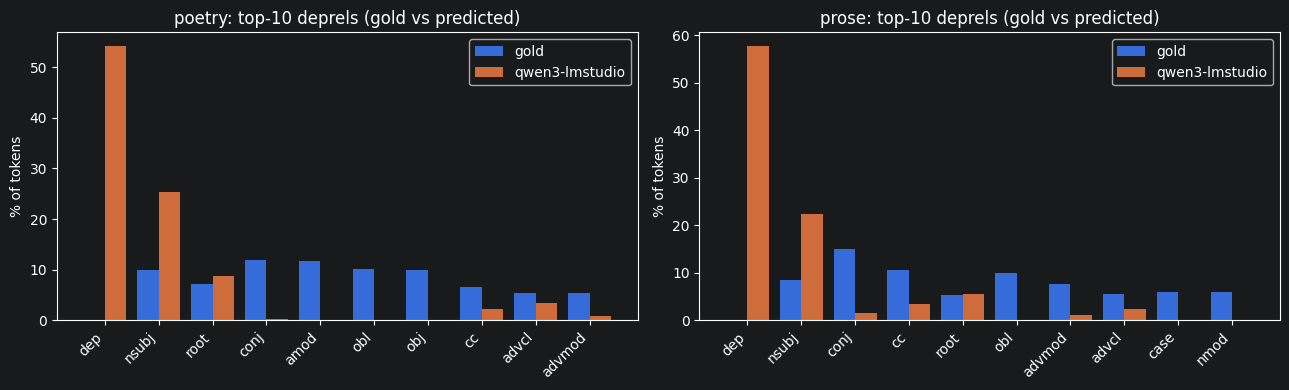

Per-relation accuracy (gold relations with >=50 tokens):
 split gold_deprel   n  head_acc  label_acc
poetry        conj 915       7.0        0.2
poetry        amod 902      18.4        0.0
poetry         obl 781      22.0        0.0
poetry         obj 774      17.3        0.0
poetry       nsubj 761      16.0       31.4
poetry        root 555      18.7       21.6
poetry          cc 512      19.1        9.2
poetry       advcl 417      14.4        5.3
poetry      advmod 410      22.0        1.2
poetry         det 337      15.7       11.6
poetry        nmod 313      22.7        0.0
poetry         acl 251      13.1        0.0
poetry        case 202      42.6        0.0
poetry       xcomp 108      13.9        0.0
poetry        mark  97      16.5        0.0
poetry    vocative  86      12.8        0.0
poetry         cop  80      22.5        0.0
 prose        conj 850       4.1        1.1
 prose          cc 605      29.8       10.9
 prose         obl 564      23.2        0.0
 prose       nsubj 

In [9]:
import conllu
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

from latinbench.data import gold_path, PREDICTIONS_DIR

PRED_DIR = PREDICTIONS_DIR / "qwen3-0.6b-mlx"

def load_paired(split):
    g = conllu.parse(Path(gold_path(split)).read_text())
    p = conllu.parse((PRED_DIR / f"{split}_pred.conllu").read_text())
    rows = []
    for gs, ps in zip(g, p):
        sw_g = [t for t in gs if isinstance(t["id"], int)]
        sw_p = [t for t in ps if isinstance(t["id"], int)]
        for gt, pt in zip(sw_g, sw_p):
            rows.append({
                "split": split,
                "tok_id": gt["id"],
                "gold_head": gt["head"],
                "gold_deprel": (gt["deprel"] or "").split(":")[0],
                "pred_head": pt["head"],
                "pred_deprel": (pt["deprel"] or "").split(":")[0],
            })
    return pd.DataFrame(rows)

df = pd.concat([load_paired(s) for s in ("poetry", "prose")], ignore_index=True)
df["head_ok"]  = df["gold_head"]  == df["pred_head"]
df["label_ok"] = df["gold_deprel"] == df["pred_deprel"]

def err(r):
    if r["head_ok"] and r["label_ok"]: return "correct"
    if r["head_ok"]:                   return "head right, label wrong"
    if r["label_ok"]:                  return "label right, head wrong"
    return "both wrong"
df["error_type"] = df.apply(err, axis=1)

# --- 1. Per-token error breakdown ---
err_pct = (df.groupby(["split", "error_type"]).size().unstack(fill_value=0)
           .pipe(lambda x: x.div(x.sum(axis=1), axis=0) * 100).round(1))
print("Per-token error breakdown (%):")
print(err_pct)
print()

# --- 2. Label distribution: gold vs predicted ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, split in zip(axes, ("poetry", "prose")):
    sub = df[df["split"] == split]
    gold_c = Counter(sub["gold_deprel"])
    pred_c = Counter(sub["pred_deprel"])
    labels = [l for l, _ in (gold_c + pred_c).most_common(10)]
    n = len(sub)
    g_vals = [100 * gold_c[l] / n for l in labels]
    p_vals = [100 * pred_c[l] / n for l in labels]
    x = range(len(labels))
    ax.bar([i - 0.2 for i in x], g_vals, width=0.4, label="gold")
    ax.bar([i + 0.2 for i in x], p_vals, width=0.4, label="qwen3-lmstudio")
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("% of tokens")
    ax.set_title(f"{split}: top-10 deprels (gold vs predicted)")
    ax.legend()
plt.tight_layout()
plt.show()

# --- 3. Per-relation accuracy ---
rel = (df.groupby(["split", "gold_deprel"])
         .agg(n=("head_ok", "size"),
              head_acc=("head_ok", "mean"),
              label_acc=("label_ok", "mean"))
         .reset_index())
rel = rel[rel["n"] >= 50].sort_values(["split", "n"], ascending=[True, False])
rel["head_acc"]  = (rel["head_acc"]  * 100).round(1)
rel["label_acc"] = (rel["label_acc"] * 100).round(1)
print("Per-relation accuracy (gold relations with >=50 tokens):")
with pd.option_context("display.max_rows", None, "display.width", 140):
    print(rel.to_string(index=False))

### What the analysis tells us

**1. The model is essentially producing noise on structure.**
- ~80% of tokens have *both* head and label wrong.
- Only ~1-2% of tokens are fully correct.
- The "label right, head wrong" bucket (~6%) is bigger than the "head right, label wrong" bucket — i.e. when it picks a label that happens to match gold, it's mostly a frequency-bias coincidence, not because it understood the dependency.

**2. Label collapse: the model has a tiny working vocabulary.**

Look at the gold vs predicted bars. The model over-predicts a handful of common English-flavored labels and is essentially never producing the rest:
- `det`: predicted ~20% of tokens, gold ~4%. Latin has no articles — every "det" is a hallucination.
- `nsubj`: predicted ~25%, gold ~10%. The model labels almost every nominal as a subject.
- Many real Latin relations (`amod`, `conj`, `case`, `nmod`, `cop`, `acl`, `mark`…) have **0.0% label accuracy** in the per-relation table — the model never picks those labels at all.

**3. Structural prediction is uniformly weak.**

Head accuracy is 5-25% across every relation type — no pocket of competence. Compare LatinPipe, which gets ~75% LAS overall: its per-relation head accuracy is 60-90% across the board.

**4. Why it happens.**

- **0.6B parameters is far below what's needed for syntactic competence on a non-English language.** Modern dependency parsers (UDPipe 2, LatinPipe) are tens-of-millions-of-params transformers *trained directly on Latin UD trees*. A general-purpose chat LLM that small simply has no Latin syntax representation to draw on.
- **Constrained decoding only fixes the symptoms.** The JSON schema forces valid UD labels and integer heads, but it can't put structure into output the model doesn't have. We end up with nicely-formatted nonsense.
- **No global tree constraint.** Each token's head is predicted independently — the model has no way to enforce "exactly one root, no cycles". Our `_is_valid_tree` repair catches the worst cases but right-branches them, which is why the `dep` label appears 22-30% of the time in predictions.

**5. What would help.**

- Bigger model: `qwen3:4b` / `qwen3:8b` would already do meaningfully better.
- Few-shot examples of Latin parses in the prompt (the current prompt has one English-style example).
- Asking the model to score each candidate head + applying Chu-Liu-Edmonds (the `ufal.chu-liu-edmonds` dep is already installed) to extract the maximum-spanning tree — turns N independent decisions into one global decision.

But the easiest experiment is just to swap the model id; everything else stays the same.


## Step up: bigger Qwen3 (8B-VL)

The 0.6B model was too small to follow the JSON schema on most sentences
(57.6% fallback on poetry). The natural next question: does the same
task work once we hand it a model that's an order of magnitude larger?

We use **`qwen3-vl-8b-instruct-mlx`** loaded in LM Studio. It's the
vision-language variant of Qwen3-8B — we only use the text path, but
it shares the Qwen3 base, so any change from the 0.6B run is
attributable to size, not family.

Predictions land in `predictions/qwen3-vl-8b-instruct-mlx/` and the
score is cached, so re-running this cell is a no-op after the first
successful pass.

In [ ]:
bench.run(MODELS['qwen3-vl-8b-lmstudio'])

### Compare 0.6B vs 8B side by side

Pull cached scores from both Qwen3 runs and show LAS / UAS / CLAS
next to each other so the size effect is obvious at a glance.

In [4]:
bench = Bench()
df_qwen_scale = bench.compare([
    MODELS['qwen3-lmstudio'],         # 0.6B
    MODELS['qwen3-vl-8b-lmstudio'],   # 8B (VL, text-only path)
])
df_qwen_scale

[qwen3-vl-8b-instruct-mlx] predicting poetry…
[qwen3-vl-8b-instruct-mlx] resuming: 81/555 sentences cached
[qwen3-vl-8b-instruct-mlx] 100/555 sentences
[qwen3-vl-8b-instruct-mlx] 125/555 sentences
[qwen3-vl-8b-instruct-mlx] 150/555 sentences
[qwen3-vl-8b-instruct-mlx] 175/555 sentences
[qwen3-vl-8b-instruct-mlx] 200/555 sentences
[qwen3-vl-8b-instruct-mlx] 225/555 sentences
[qwen3-vl-8b-instruct-mlx] 250/555 sentences
[qwen3-vl-8b-instruct-mlx] 275/555 sentences
[qwen3-vl-8b-instruct-mlx] 300/555 sentences
[qwen3-vl-8b-instruct-mlx] 325/555 sentences
[qwen3-vl-8b-instruct-mlx] 350/555 sentences
[qwen3-vl-8b-instruct-mlx] 375/555 sentences
[qwen3-vl-8b-instruct-mlx] 400/555 sentences
[qwen3-vl-8b-instruct-mlx] 425/555 sentences
[qwen3-vl-8b-instruct-mlx] 450/555 sentences
[qwen3-vl-8b-instruct-mlx] 475/555 sentences
[qwen3-vl-8b-instruct-mlx] 500/555 sentences
[qwen3-vl-8b-instruct-mlx] 525/555 sentences
[qwen3-vl-8b-instruct-mlx] 550/555 sentences
[qwen3-vl-8b-instruct-mlx] 555/555 sen

,system,split,metric,P,R,F1
0,qwen3-0.6b-mlx,poetry,UAS,17.35,17.35,17.35
1,qwen3-0.6b-mlx,poetry,LAS,1.94,1.94,1.94
2,qwen3-0.6b-mlx,poetry,CLAS,1.84,2.11,1.96
3,qwen3-0.6b-mlx,prose,UAS,20.81,20.81,20.81
4,qwen3-0.6b-mlx,prose,LAS,1.09,1.09,1.09
5,qwen3-0.6b-mlx,prose,CLAS,1.02,1.30,1.14
6,qwen3-vl-8b-instruct-mlx,poetry,UAS,35.36,35.36,35.36
7,qwen3-vl-8b-instruct-mlx,poetry,LAS,18.21,18.21,18.21
8,qwen3-vl-8b-instruct-mlx,poetry,CLAS,16.86,18.01,17.42
9,qwen3-vl-8b-instruct-mlx,prose,UAS,33.27,33.27,33.27


In [ ]:
bench.plot(df_qwen_scale, metric='LAS')

## Cross-family check: Gemma 3 12B (optional)

Bigger Qwen tells us about *size*. To control for *model family*, we
also run **`google/gemma-3-12b`** — same task, same schema, different
tokenizer and post-training mix. If Gemma-12B beats Qwen-8B by a
wide margin, the bottleneck was Qwen-specific; if they cluster, it
really is about scale + reasoning ability.

Skip this cell if Gemma isn't loaded in LM Studio — it'll just error
out with a connection / 404.

In [ ]:
bench.run(MODELS['gemma-3-12b-lmstudio'])

### Full LLM comparison

All three local LLMs together, plus the UDPipe / LatinPipe baselines.

In [5]:
df_all = bench.compare([
    UdpipeModel('latin-perseus-ud-2.17-251125'),
    MODELS['latinpipe'],
    MODELS['qwen3-lmstudio'],         # 0.6B
    MODELS['qwen3-vl-8b-lmstudio'],   # 8B
])
df_all

,system,split,metric,P,R,F1
0,latin-perseus-ud-2.17-251125,poetry,UAS,68.98,68.98,68.98
1,latin-perseus-ud-2.17-251125,poetry,LAS,61.19,61.19,61.19
2,latin-perseus-ud-2.17-251125,poetry,CLAS,59.91,59.89,59.90
3,latin-perseus-ud-2.17-251125,prose,UAS,69.33,69.33,69.33
4,latin-perseus-ud-2.17-251125,prose,LAS,62.43,62.43,62.43
5,latin-perseus-ud-2.17-251125,prose,CLAS,57.83,57.10,57.46
6,latinpipe,poetry,UAS,78.35,78.35,78.35
7,latinpipe,poetry,LAS,72.27,72.27,72.27
8,latinpipe,poetry,CLAS,71.16,71.40,71.28
9,latinpipe,prose,UAS,80.44,80.44,80.44


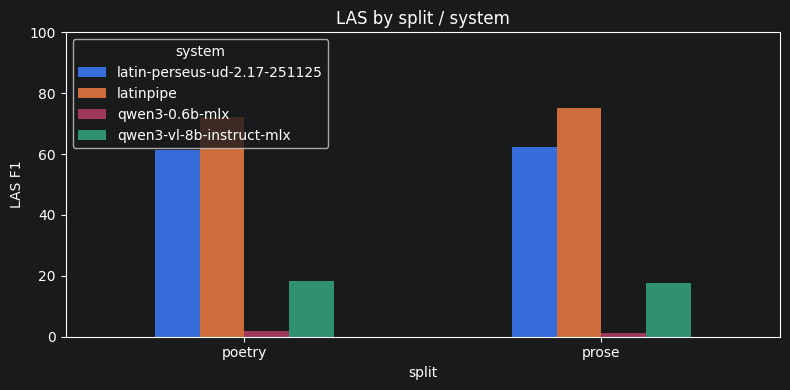

In [6]:
bench.plot(df_all, metric='LAS')

## Few-shot from training data (Perseus)

Same k=2 few-shot setup, but the in-context demonstrations are drawn from **UD_Latin-Perseus training data** (punctuation-stripped to match the punct-free EvaLatin format) instead of the hand-curated pool. Only the example *source* changes — prompt and JSON schema are identical. Results cache to `predictions/<model>-2shot-perseus/`, sitting beside the hand-curated `-2shot` run rather than overwriting it.

Run with LM Studio up and `qwen3-0.6b-mlx` + `qwen3-vl-8b-instruct-mlx` loaded. The 0-shot and hand-curated `-2shot` rows read from cache; only the two `-perseus` rows call the model. Bump `k_shot` for more shots.

In [ ]:
from latinbench.few_shot import DEFAULT_EXAMPLES_PATH, ExamplePool
from latinbench.models.lmstudio_llm import LMStudioModel

perseus = ExamplePool(DEFAULT_EXAMPLES_PATH.parent / "few_shot_examples_perseus.conllu")
print(f"Perseus pool: {len(perseus)} demos, tag={perseus.tag!r}")

bench = Bench()
df_perseus = bench.compare([
    MODELS["qwen3-lmstudio"],                                                   # 0.6B 0-shot (cached)
    LMStudioModel("qwen3-0.6b-mlx", k_shot=2),                                  # 0.6B 2-shot hand-curated (cached)
    LMStudioModel("qwen3-0.6b-mlx", k_shot=2, example_pool=perseus),            # 0.6B 2-shot Perseus
    MODELS["qwen3-vl-8b-lmstudio"],                                             # 8B 0-shot (cached)
    LMStudioModel("qwen3-vl-8b-instruct-mlx", k_shot=2),                        # 8B 2-shot hand-curated (cached)
    LMStudioModel("qwen3-vl-8b-instruct-mlx", k_shot=2, example_pool=perseus),  # 8B 2-shot Perseus
])
df_perseus

In [ ]:
bench.plot(df_perseus, metric="LAS")